# RPT API — Interviewer Solution

> **For the interviewer only. Do not share with candidates.**

Each task section contains:
- What the task tests
- Model answer (code + output)
- Strong signals (what a senior candidate does well)
- Red flags (what weak candidates do)

In [ ]:
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, r2_score

with open('config.json') as f:
    _cfg = json.load(f)

API_TOKEN = _cfg['RPT_TOKEN']
API_URL   = _cfg['RPT_API_URL']
HEADERS   = {'Authorization': f'Bearer {API_TOKEN}', 'Content-Type': 'application/json'}

def get_payload(context_df, eval_df_batch, target_col='current_annual_salary'):
    context_rows = json.loads(context_df.to_json(orient='records'))
    eval_copy = eval_df_batch.copy()
    eval_copy[target_col] = '[PREDICT]'
    eval_rows = json.loads(eval_copy.to_json(orient='records'))
    return {'rows': context_rows + eval_rows}

def get_response(payload):
    response = requests.post(API_URL, headers=HEADERS, json=payload, timeout=30)
    if not response.ok:
        print(f'Error {response.status_code}: {response.text}')
    response.raise_for_status()
    return response.json()

def get_predictions(result, target_col='current_annual_salary'):
    return pd.json_normalize(
        result['prediction']['predictions'],
        record_path=target_col
    )['prediction'].astype(float).values

def plot_distribution(series, title='Salary distribution'):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(series.dropna(), bins=60, edgecolor='none')
    ax.axvline(series.median(), color='red', linestyle='--', label=f'Median ${series.median():,.0f}')
    ax.set_title(title)
    ax.set_xlabel('Annual salary (USD)')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_predicted_vs_actual(y_true, y_pred, title='Predicted vs. actual salary'):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.7)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', label='perfect fit')
    ax.set_xlabel('Actual salary (USD)')
    ax.set_ylabel('Predicted salary (USD)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Task 1 — Data Audit

**Tests:** Attention to data quality, domain awareness, redundancy detection, leakage instinct

**Strong signals:**
- Notices `date_first_hired` and `year_first_hired` encode the same information
- Verifies that `department` and `department_name` have a perfect 1:1 mapping — not just equal unique counts
- Flags the slight right skew (skew ≈ 0.88, mean $73k vs. median $69k) and the high-salary outliers
- Asks: what does "fair" salary mean compared to role, seniority, market?
- Questions whether the data has what's needed to answer the stakeholder's question at all

**Red flags:**
- Just runs `df.describe()` and moves on
- Does not question which columns are safe to use
- Does not notice the redundancy between date columns

In [2]:
df = pd.read_csv('employee_salaries.csv')

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Shape: (9228, 10)

Dtypes:
gender                      object
department                  object
department_name             object
division                    object
assignment_category         object
employee_position_title     object
date_first_hired            object
year_first_hired             int64
current_annual_salary      float64
is_eval                      int64
dtype: object

Missing values:
gender                     17
department                  0
department_name             0
division                    0
assignment_category         0
employee_position_title     0
date_first_hired            0
year_first_hired            0
current_annual_salary       0
is_eval                     0
dtype: int64


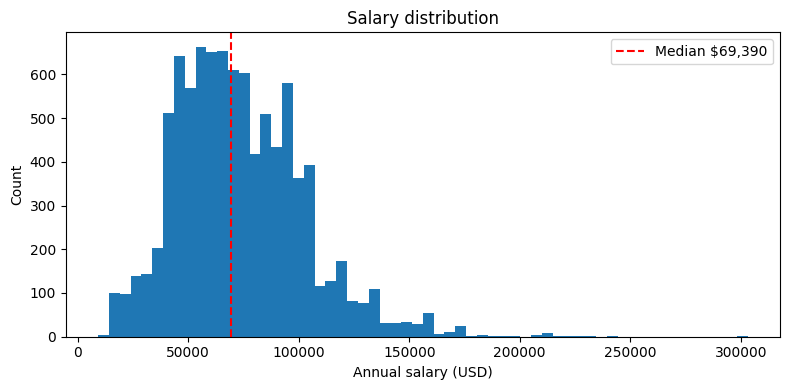

In [3]:
plot_distribution(df['current_annual_salary'])

In [4]:
# date_first_hired vs year_first_hired — same information
print(df[['date_first_hired', 'year_first_hired']].head(5))

# department vs department_name — verify 1:1 mapping, not just equal counts
names_per_code = df.groupby('department')['department_name'].nunique()
print('\nMax department_names per department code:', names_per_code.max())
print('→ Perfect 1:1 mapping:', (names_per_code == 1).all())

  date_first_hired  year_first_hired
0       09/03/1991              1991
1       02/05/2007              2007
2       01/06/1997              1997
3       01/28/2014              2014
4       02/01/1999              1999

Max department_names per department code: 1
→ Perfect 1:1 mapping: True


In [5]:
# Part-time vs full-time — structurally different populations
df.groupby('assignment_category')['current_annual_salary'].describe()

,count,mean,std,min,25%,50%,75%,max
assignment_category,,,,,,,,
Fulltime-Regular,8394.0,77146.194495,27326.284784,9196.0,56733.00,72902.00,92756.700,303091.0
Parttime-Regular,834.0,35586.822554,17192.930166,13244.5,24134.31,30257.86,42475.515,171386.1


---
## Task 2 — Feature Engineering

**Tests:** Domain-driven feature creation, pandas proficiency, knowing what adds vs. hurts signal

**Strong signals:**
- Derives `tenure_years = 2016 - year_first_hired` (not just copies the year)
- Drops `date_first_hired` after extracting tenure (raw date string adds no value)
- Drops `department` (redundant with `department_name`)
- Explains reasoning, not just executes

**Red flags:**
- Keeps all columns without justification
- Drops columns without explanation
- Creates `is_fulltime` binary — RPT reads the string directly, binary encoding loses information (there are more than 2 categories)
- Creates features that leak the target

In [6]:
df = pd.read_csv('employee_salaries.csv')
df_clean = df.copy()

# Tenure: years of service as of 2016 — more interpretable than the raw year
df_clean['tenure_years'] = 2016 - df_clean['year_first_hired']

# Drop redundant / raw columns
df_clean = df_clean.drop(columns=['date_first_hired', 'year_first_hired', 'department'])

print(df_clean.columns.tolist())
df_clean.head()

['gender', 'department_name', 'division', 'assignment_category', 'employee_position_title', 'current_annual_salary', 'is_eval', 'tenure_years']


,gender,department_name,division,assignment_category,employee_position_title,current_annual_salary,is_eval,tenure_years
0,M,Department of Liquor Control,Clarksburg Village,Parttime-Regular,Liquor Store Clerk I,54022.26,0,25
1,F,Department of Police,FSB Traffic Division Automated Traffic Enforce...,Fulltime-Regular,Police Aide,46626.06,0,9
2,F,Correction and Rehabilitation,DS MCCF Case Managers Unit 1,Fulltime-Regular,Correctional Specialist IV,97153.42,0,19
3,F,Office of Procurement,Procurement Director,Fulltime-Regular,Director Office of Procurement,190550.00,0,2
4,M,Department of Health and Human Services,Income Supports,Fulltime-Regular,Income Assistance Program Specialist II,73819.32,0,17


---
## Task 3 — First Prediction

**Tests:** API usage, understanding in-context learning, sanity-checking outputs, not blindly trusting the model

**Strong signals:**
- Notices that `context_df` has 9,203 rows and the API max is 2,048 — samples down before calling
- Compares predicted to actual and comments on the delta
- Notes that context quality/size affects the prediction
- Does not just run the call — thinks about what the model sees

**Red flags:**
- Sends all 9,203 context rows → 400 error, doesn't read the constraints
- Does not compare prediction to actual
- Accepts the result without any sanity check

In [7]:
df = pd.read_csv('employee_salaries.csv')

context_df = df[df['is_eval'] == 0].drop(columns='is_eval')
eval_df    = df[df['is_eval'] == 1].drop(columns='is_eval')

# API max: 2048 context rows. Sample a representative subset.
context_sample = context_df.sample(2048, random_state=42)

query_row     = eval_df.iloc[[0]]
actual_salary = query_row['current_annual_salary'].values[0]

payload   = get_payload(context_sample, query_row)
result    = get_response(payload)
predicted = get_predictions(result)[0]

print(f'Actual:    ${actual_salary:,.0f}')
print(f'Predicted: ${predicted:,.0f}')
print(f'Delta:     ${abs(actual_salary - predicted):,.0f}  ({abs(actual_salary - predicted) / actual_salary:.1%})')

Actual:    $105,744
Predicted: $102,398
Delta:     $3,346  (3.2%)


---
## Task 4 — Model Evaluation

**Tests:** Evaluation methodology, metric interpretation, business contextualization, understanding that 25 rows = 1 call (no loop needed)

**Strong signals:**
- Recognizes that all 25 eval rows fit in one API call — no batch loop needed
- Handles the 2,048 context row limit — samples `context_df` before calling
- Reports RMSE in dollar terms alongside R2
- Contextualizes: RMSE / median salary = relative error
- Does not conflate R2 with "good enough for business use"
- Plots predicted vs. actual
- Remembers to drop `is_eval` before sending to API

**Red flags:**
- Sends all 9,203 context rows → 400 error
- Writes an unnecessary batch loop over eval rows
- Only prints MSE without interpreting it in dollar terms
- Claims model is "good" based on R2 alone
- Forgets to drop `is_eval` — sends it as a feature

In [8]:
df = pd.read_csv('employee_salaries.csv')

context_df = df[df['is_eval'] == 0].drop(columns='is_eval')
eval_df    = df[df['is_eval'] == 1].drop(columns='is_eval')

context_sample = context_df.sample(2048, random_state=42)

payload  = get_payload(context_sample, eval_df)
result   = get_response(payload)
y_pred   = get_predictions(result)
y_true   = eval_df['current_annual_salary'].values

rmse       = root_mean_squared_error(y_true, y_pred)
r2         = r2_score(y_true, y_pred)
median_sal = df['current_annual_salary'].median()

print(f"R2:   {r2:.3f}")
print(f"RMSE: ${rmse:,.0f}  ({rmse / median_sal:.1%} of median salary ${median_sal:,.0f})")

R2:   0.929
RMSE: $6,484  (9.3% of median salary $69,390)


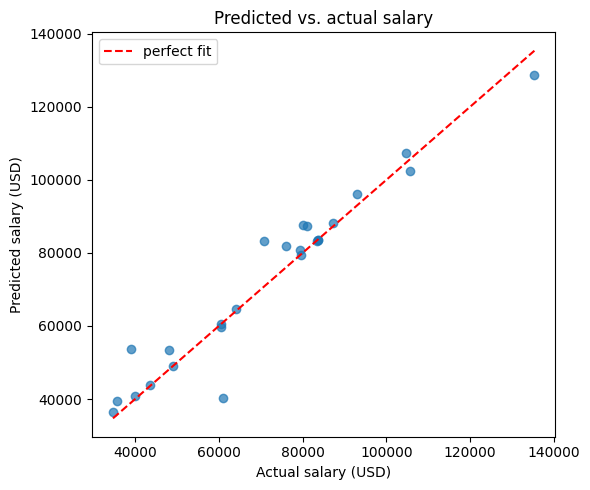

In [9]:
plot_predicted_vs_actual(y_true, y_pred)

---
## Task 5 — Salary Patterns & Pay Equity

**Tests:** Critical thinking about data limitations, ability to push back on unanswerable questions, hypothesis-driven EDA

**The key insight the candidate should reach:**  
Part-time consistency cannot be properly tested with this dataset — there is no hours/FTE column. `current_annual_salary` for a part-timer is not comparable to a full-timer's without knowing their hours. A strong candidate recognizes this and says so explicitly rather than building an analysis that looks plausible but is meaningless.

**Strong signals:**
- Immediately flags the missing hours/FTE data as a blocker for the Finance question
- Proposes what data would be needed to answer it properly (hourly rate, contracted hours, FTE ratio)
- Still does useful EDA on what *can* be analyzed: salary variance within job titles, department differences, tenure effects
- Notes that RPT sees `assignment_category` directly — no need to separate context pools by employment type
- Frames findings carefully: "this pattern is worth investigating" rather than "this proves discrimination"

**Red flags:**
- Compares raw annual salaries between part-time and full-time and draws conclusions
- Does not notice the missing hours dimension
- Separates context pools by employment type "because they're different" (classic ML thinking, not RPT thinking)
- Over-interprets correlation as discrimination without controlling for role or tenure

In [10]:
df = pd.read_csv('employee_salaries.csv')

# Gender pay gap — but control for department
print('=== Median salary by gender ===')
print(df.groupby('gender')['current_annual_salary'].median())

print('\n=== Median salary by gender within top departments ===')
top_depts = df['department_name'].value_counts().index
print(df[df['department_name'].isin(top_depts)]
      .groupby(['department_name', 'gender'])['current_annual_salary']
      .median().unstack())

=== Median salary by gender ===
gender
F    68550.12
M    70435.00
Name: current_annual_salary, dtype: float64

=== Median salary by gender within top departments ===
gender                                                       F           M
department_name                                                           
Board of Appeals Department                          72442.200         NaN
Board of Elections                                   69488.325   63634.435
Community Engagement Cluster                         81501.890   42020.030
Community Use of Public Facilities                   66477.890   69222.180
Correction and Rehabilitation                        70301.000   69316.940
County Attorney's Office                             89371.685  140794.000
County Council                                       78293.440  111621.420
Department of Environmental Protection               81066.810   88546.765
Department of Finance                                85782.890  106700.460
Departme

In [11]:
# Salary variance within same job title — high variance = potential inequity
title_stats = (df.groupby('employee_position_title')['current_annual_salary']
               .agg(['count', 'std', 'median'])
               .query('count >= 10')
               .sort_values('std', ascending=False)
               .head(10))
title_stats.columns = ['count', 'salary_std', 'salary_median']
print('=== Job titles with highest salary variance (min 10 employees) ===')
print(title_stats)

=== Job titles with highest salary variance (min 10 employees) ===
                               count    salary_std  salary_median
employee_position_title                                          
Library Associate II              22  24248.176268      41755.955
Assistant County Attorney III     30  20709.045335     139016.045
Librarian I                       52  19251.837365      43761.610
Therapist II                      82  19065.644148      90204.945
Client Assistance Specialist      37  17341.214648      64614.650
Librarian II                      39  17165.519306      75928.990
Social Worker III                103  16436.358681      86668.490
Investigator III                  23  16187.774742      97103.070
Forensic Scientist                12  16070.410014      77408.170
Library Assistant I               86  15171.221295      30100.720
